Import Libraries
---



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
df = pd.read_csv("frequent_itemsets.csv")
print(df.head())

   support                          itemsets
0   0.0568      frozenset({'Air Freshener'})
1   0.0608          frozenset({'Apple 1kg'})
2   0.0600         frozenset({'Banana 1kg'})
3   0.0578  frozenset({'Banana Chips 150g'})
4   0.0604      frozenset({'Bar Soap 125g'})


Dataset Information

In [3]:
print("Dataset Information:")
print(df.info())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   support   256 non-null    float64
 1   itemsets  256 non-null    object 
dtypes: float64(1), object(1)
memory usage: 4.1+ KB
None

Dataset Shape:
(256, 2)

Column Names:
['support', 'itemsets']

Missing Values:
support     0
itemsets    0
dtype: int64


Basic Dataset Analysis

In [4]:
print("Number of Frequent Itemsets:", len(df))
print("\nData Types:")
print(df.dtypes)
print("\nSupport Statistics:")
print(df["support"].describe())

Number of Frequent Itemsets: 256

Data Types:
support     float64
itemsets     object
dtype: object

Support Statistics:
count    256.000000
mean       0.051328
std        0.043372
min        0.020200
25%        0.029350
50%        0.036800
75%        0.056800
max        0.254600
Name: support, dtype: float64


Display All Frequent Itemsets

In [5]:
print(df.to_string(index=False))

 support                                                                                               itemsets
  0.0568                                                                           frozenset({'Air Freshener'})
  0.0608                                                                               frozenset({'Apple 1kg'})
  0.0600                                                                              frozenset({'Banana 1kg'})
  0.0578                                                                       frozenset({'Banana Chips 150g'})
  0.0604                                                                           frozenset({'Bar Soap 125g'})
  0.1982                                                                        frozenset({'Basmati Rice 5kg'})
  0.0668                                                                               frozenset({'Besan 1kg'})
  0.0588                                                                        frozenset({'Brown Bread 

Convert Itemsets to Strings

In [6]:
df["itemsets"] = df["itemsets"].astype(str)
print(df.head(10))

   support                          itemsets
0   0.0568      frozenset({'Air Freshener'})
1   0.0608          frozenset({'Apple 1kg'})
2   0.0600         frozenset({'Banana 1kg'})
3   0.0578  frozenset({'Banana Chips 150g'})
4   0.0604      frozenset({'Bar Soap 125g'})
5   0.1982   frozenset({'Basmati Rice 5kg'})
6   0.0668          frozenset({'Besan 1kg'})
7   0.0588   frozenset({'Brown Bread 400g'})
8   0.0626        frozenset({'Butter 100g'})
9   0.0670      frozenset({'Buttermilk 1L'})


Extract Itemset Size

In [7]:
import re
def get_itemset_size(itemset):
    return len(re.findall(r"'[^']+'", itemset))
df["itemset_size"] = df["itemsets"].apply(get_itemset_size)
print(df.head(10))

   support                          itemsets  itemset_size
0   0.0568      frozenset({'Air Freshener'})             1
1   0.0608          frozenset({'Apple 1kg'})             1
2   0.0600         frozenset({'Banana 1kg'})             1
3   0.0578  frozenset({'Banana Chips 150g'})             1
4   0.0604      frozenset({'Bar Soap 125g'})             1
5   0.1982   frozenset({'Basmati Rice 5kg'})             1
6   0.0668          frozenset({'Besan 1kg'})             1
7   0.0588   frozenset({'Brown Bread 400g'})             1
8   0.0626        frozenset({'Butter 100g'})             1
9   0.0670      frozenset({'Buttermilk 1L'})             1


Count Itemsets by Size

In [8]:
itemset_counts = df["itemset_size"].value_counts().sort_index()
print("Itemsets by Size:")
print(itemset_counts)

Itemsets by Size:
itemset_size
1    60
2    78
3    86
4    30
5     2
Name: count, dtype: int64


Visualize Itemset Sizes

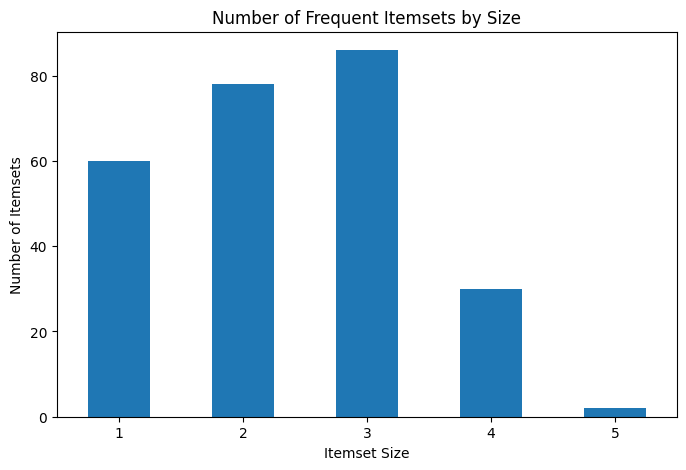

In [9]:
plt.figure(figsize=(8,5))
itemset_counts.plot(kind="bar")
plt.title("Number of Frequent Itemsets by Size")
plt.xlabel("Itemset Size")
plt.ylabel("Number of Itemsets")
plt.xticks(rotation=0)

plt.show()

Top Frequent Itemsets

In [10]:
top_itemsets = df.sort_values(
    by="support",
    ascending=False
).head(10)
print("Top 10 Frequent Itemsets:")
print(top_itemsets[["support", "itemsets"]])

Top 10 Frequent Itemsets:
     support                                          itemsets
59    0.2546                   frozenset({'White Bread 400g'})
55    0.2540                      frozenset({'Toned Milk 1L'})
136   0.2384  frozenset({'Toned Milk 1L', 'White Bread 400g'})
44    0.2184                   frozenset({'Potato Chips 90g'})
14    0.2164                         frozenset({'Cola 750ml'})
56    0.2068                       frozenset({'Toor Dal 1kg'})
15    0.1996                     frozenset({'Cooking Oil 1L'})
5     0.1982                   frozenset({'Basmati Rice 5kg'})
89    0.1974     frozenset({'Cola 750ml', 'Potato Chips 90g'})
13    0.1776                 frozenset({'Choco Cookies 150g'})


Top Itemsets Bar Chart

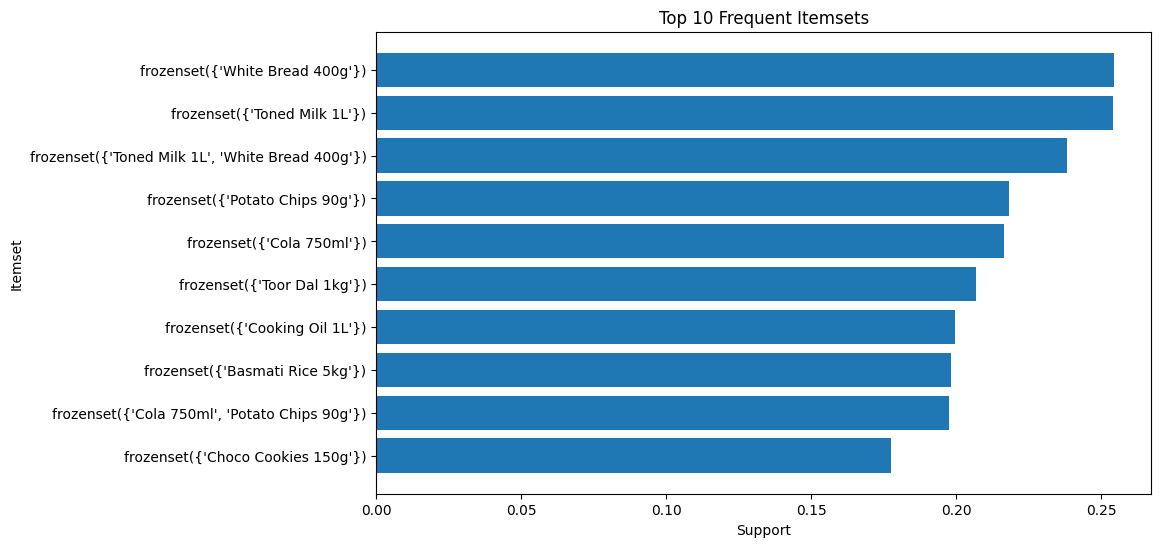

In [11]:
top10 = df.sort_values(
    by="support",
    ascending=False
).head(10)
plt.figure(figsize=(10,6))
plt.barh(
    top10["itemsets"].astype(str),
    top10["support"]
)
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.title("Top 10 Frequent Itemsets")
plt.gca().invert_yaxis()
plt.show()

Support Distribution

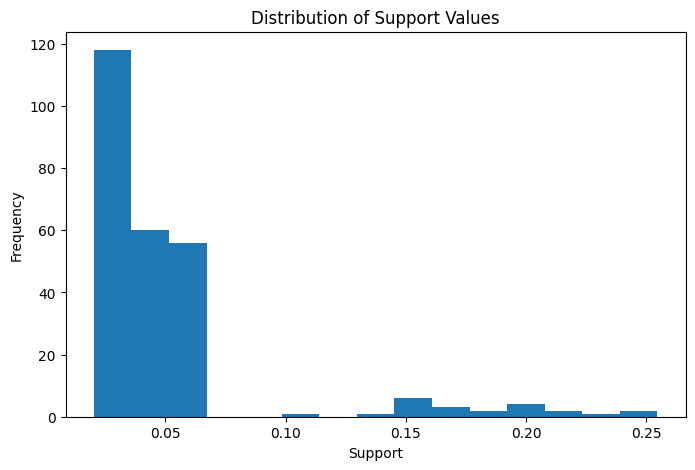

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["support"], bins=15)
plt.xlabel("Support")
plt.ylabel("Frequency")
plt.title("Distribution of Support Values")
plt.show()

Support by Itemset Size

In [13]:
support_by_size = df.groupby(
    "itemset_size"
)["support"].mean()
print("Average Support by Itemset Size:")
print(support_by_size)

Average Support by Itemset Size:
itemset_size
1    0.089593
2    0.051587
3    0.033367
4    0.027460
5    0.023600
Name: support, dtype: float64


Support Comparison

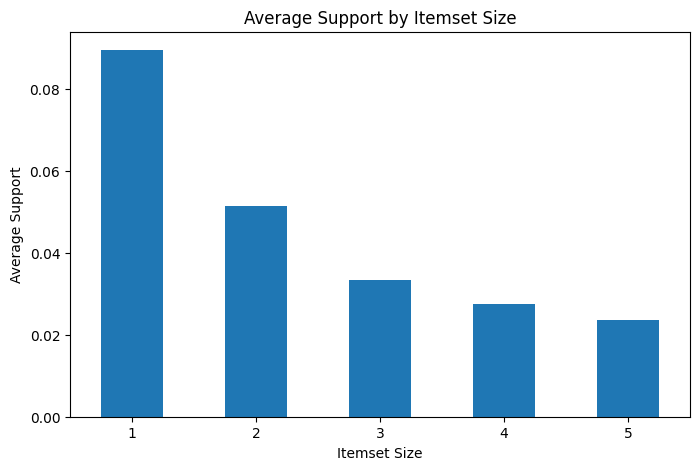

In [14]:
plt.figure(figsize=(8,5))
support_by_size.plot(kind="bar")
plt.title("Average Support by Itemset Size")
plt.xlabel("Itemset Size")
plt.ylabel("Average Support")
plt.xticks(rotation=0)
plt.show()

Highest Support Itemset

In [15]:
highest = df.loc[df["support"].idxmax()]
print("Highest Support Itemset:")
print("Itemset:", highest["itemsets"])
print("Support:", highest["support"])

Highest Support Itemset:
Itemset: frozenset({'White Bread 400g'})
Support: 0.2546


Lowest Support Itemset

In [16]:
lowest = df.loc[df["support"].idxmin()]
print("Lowest Support Itemset:")
print("Itemset:", lowest["itemsets"])
print("Support:", lowest["support"])

Lowest Support Itemset:
Itemset: frozenset({'Choco Cookies 150g', 'Basmati Rice 5kg', 'Toor Dal 1kg', 'Cooking Oil 1L'})
Support: 0.0202


Itemsets with Support Greater Than 10%

In [17]:
high_support = df[df["support"] >= 0.10]
print("Itemsets with Support >= 10%:")
print(high_support[["support", "itemsets"]])

Itemsets with Support >= 10%:
     support                                           itemsets
5     0.1982                    frozenset({'Basmati Rice 5kg'})
13    0.1776                  frozenset({'Choco Cookies 150g'})
14    0.2164                          frozenset({'Cola 750ml'})
15    0.1996                      frozenset({'Cooking Oil 1L'})
23    0.1570                     frozenset({'Face Wash 100ml'})
26    0.1706                          frozenset({'Ghee 500ml'})
28    0.1662                frozenset({'Hand Sanitizer 200ml'})
29    0.1770                 frozenset({'Instant Coffee 100g'})
41    0.1698                           frozenset({'Poha 500g'})
44    0.2184                    frozenset({'Potato Chips 90g'})
55    0.2540                       frozenset({'Toned Milk 1L'})
56    0.2068                        frozenset({'Toor Dal 1kg'})
59    0.2546                    frozenset({'White Bread 400g'})
62    0.1462  frozenset({'Basmati Rice 5kg', 'Cooking Oil 1L'})
70    0.15

Itemsets with Support Between 5% and 10%

In [18]:
medium_support = df[
    (df["support"] >= 0.05) &
    (df["support"] < 0.10)
]
print("Itemsets with Support Between 5% and 10%:")
print(medium_support[["support", "itemsets"]])

Itemsets with Support Between 5% and 10%:
     support                                           itemsets
0     0.0568                       frozenset({'Air Freshener'})
1     0.0608                           frozenset({'Apple 1kg'})
2     0.0600                          frozenset({'Banana 1kg'})
3     0.0578                   frozenset({'Banana Chips 150g'})
4     0.0604                       frozenset({'Bar Soap 125g'})
6     0.0668                           frozenset({'Besan 1kg'})
7     0.0588                    frozenset({'Brown Bread 400g'})
8     0.0626                         frozenset({'Butter 100g'})
9     0.0670                       frozenset({'Buttermilk 1L'})
10    0.0564                       frozenset({'Capsicum 500g'})
11    0.0548                         frozenset({'Carrot 500g'})
12    0.0596                  frozenset({'Cheese Slices 200g'})
16    0.0628                       frozenset({'Croissant 2pc'})
17    0.0614                       frozenset({'Cucumber 500g'}

Check Six Important Patterns

In [19]:
patterns = [
    "Toned Milk",
    "Basmati Rice",
    "Potato Chips",
    "Ghee",
    "Instant Coffee",
    "Hand Sanitizer"
]
for pattern in patterns:
    result = df[
        df["itemsets"].str.contains(pattern, case=False, na=False)
    ]
    print("\n", pattern)
    print(result[["support", "itemsets"]].to_string(index=False))


 Toned Milk
 support                                                                                               itemsets
  0.2540                                                                           frozenset({'Toned Milk 1L'})
  0.0484                                                       frozenset({'Toned Milk 1L', 'Basmati Rice 5kg'})
  0.0442                                                     frozenset({'Choco Cookies 150g', 'Toned Milk 1L'})
  0.0570                                                             frozenset({'Toned Milk 1L', 'Cola 750ml'})
  0.0468                                                         frozenset({'Toned Milk 1L', 'Cooking Oil 1L'})
  0.0396                                                        frozenset({'Face Wash 100ml', 'Toned Milk 1L'})
  0.0364                                                             frozenset({'Toned Milk 1L', 'Ghee 500ml'})
  0.0444                                                   frozenset({'Toned Milk 1L', 'Han

Check Banana 1kg

In [20]:
banana = df[df["itemsets"].str.contains("Banana 1kg",case=False,na=False)]
print("Banana 1kg Itemsets:")
print(banana[["support", "itemsets"]].to_string(index=False))

Banana 1kg Itemsets:
 support                  itemsets
    0.06 frozenset({'Banana 1kg'})


Save Analysed Dataset

In [21]:
df.to_csv("quickcart_frequent_itemsets_analysis.csv",index=False)
print("Analysis file saved successfully!")

Analysis file saved successfully!


Final Project Summary

In [22]:
print("=" * 50)
print("QUICKCART MARKET BASKET ANALYSIS")
print("=" * 50)
print("Total Frequent Itemsets:", len(df))
print("\nItemsets by Size:")
print(df["itemset_size"].value_counts().sort_index())
print("\nHighest Support:")
print(df["support"].max())
print("\nLowest Support:")
print(df["support"].min())
print("\nAverage Support:")
print(df["support"].mean())
print("\nTop 5 Frequent Itemsets:")
print(df.sort_values("support",ascending=False)[["support", "itemsets"]].head(5))
print("\nAnalysis Completed Successfully!")

QUICKCART MARKET BASKET ANALYSIS
Total Frequent Itemsets: 256

Itemsets by Size:
itemset_size
1    60
2    78
3    86
4    30
5     2
Name: count, dtype: int64

Highest Support:
0.2546

Lowest Support:
0.0202

Average Support:
0.051328125

Top 5 Frequent Itemsets:
     support                                          itemsets
59    0.2546                   frozenset({'White Bread 400g'})
55    0.2540                      frozenset({'Toned Milk 1L'})
136   0.2384  frozenset({'Toned Milk 1L', 'White Bread 400g'})
44    0.2184                   frozenset({'Potato Chips 90g'})
14    0.2164                         frozenset({'Cola 750ml'})

Analysis Completed Successfully!
